In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath("C://Users//pc//Desktop//Week 3//insurance-risk-analytics//src//"))

In [80]:
from src.data_loader import load_data
from src.eda_utils import convert_to_datetime,identify_column_types,get_boolean_columns,get_date_columns
from src.eda_utils import get_numerical_columns,get_categorical_columns,descriptive_statistics
from src.eda_utils import missing_value_report,plot_histograms,plot_scatter_by_zipcode
from src.eda_utils import correlation_by_zipcode,plot_correlation_heatmap,premium_by_province
from src.eda_utils import cover_type_distribution,auto_make_distribution,plot_average_premium
from src.eda_utils import plot_cover_type_heatmap,plot_top_auto_makes,loss_ratio_by_group
from src.eda_utils import plot_boxplots,plot_individual_boxplots,calculate_loss_ratio 
from src.eda_utils import plot_loss_ratio,plot_financial_distributions,detect_outliers_iqr
from src.eda_utils import plot_claim_trends,plot_vehicle_claims,vehicle_claim_analysis
from src.eda_utils import run_eda_visualizations

print('Functions imported successfully!')
print()

Functions imported successfully!



In [5]:
# Load the insurance data
df = load_data('C:/Users/pc/Desktop/Week 3/insurance-risk-analytics/data/insurance_data.csv')
df.head()

,customerid,age,gender,province,vehicletype,annualincome,riskscore,annualpremium,deductible,ncd,...,claimed,claimamount,totalpremium,totalclaims,covertype,automake,vehiclemodel,customvalueestimate,zipcode,transactiondate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


# Task 1: Exploratory Data Analysis

### Data Summarization 

In [6]:

df, converted = convert_to_datetime(df)

c:\Users\pc\Desktop\Week 3\insurance-risk-analytics\src\eda_utils.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(df[col], errors=errors)
c:\Users\pc\Desktop\Week 3\insurance-risk-analytics\src\eda_utils.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(df[col], errors=errors)
c:\Users\pc\Desktop\Week 3\insurance-risk-analytics\src\eda_utils.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(df[col], errors=errors)
c:\Users\pc\Desktop\Week 3\insurance-risk-analytics\src\eda_utils.py:3

In [7]:
# Identify column types
result = identify_column_types(df)

# Print results
for key, value in result.items():
        print(f"{key}: {value}")

numerical_columns: ['age', 'annualincome', 'riskscore', 'annualpremium', 'deductible', 'ncd', 'pastclaims', 'claimamount', 'totalpremium', 'totalclaims', 'customvalueestimate', 'zipcode']
categorical_columns: ['customerid', 'gender', 'province', 'vehicletype', 'covertype', 'automake', 'vehiclemodel']
boolean_columns: ['claimed']
date_columns: ['transactiondate']


In [8]:
stats = descriptive_statistics(df)
print(stats)

                       count        mean   median           std      min  \
age                  10000.0     46.6835     46.0     16.717963     18.0   
annualincome         10000.0  79201.9739  72942.0  33039.939770  17202.0   
riskscore            10000.0     58.1400     57.0     14.267486     15.0   
annualpremium        10000.0   2488.1279   2307.0    735.674491    951.0   
deductible           10000.0    751.7000    500.0    500.509401    250.0   
ncd                  10000.0     20.9350     20.0     14.549122      0.0   
pastclaims           10000.0      1.0642      1.0      1.051945      0.0   
claimamount          10000.0   1314.1885      0.0   3921.864903      0.0   
totalpremium         10000.0   2488.1279   2307.0    735.674491    951.0   
totalclaims          10000.0   1314.1885      0.0   3921.864903      0.0   
customvalueestimate  10000.0  35640.5987  28522.0  22353.988238   5022.0   
zipcode              10000.0  23215.0005  20003.0  12848.332450  10001.0   

           

### Data Quality Assessment 

In [9]:
report = missing_value_report(df)
print(report)

                     missing_count  missing_percent           dtype  \
customerid                       0              0.0             str   
age                              0              0.0           int64   
gender                           0              0.0             str   
province                         0              0.0             str   
vehicletype                      0              0.0             str   
annualincome                     0              0.0           int64   
riskscore                        0              0.0           int64   
annualpremium                    0              0.0           int64   
deductible                       0              0.0           int64   
ncd                              0              0.0           int64   
pastclaims                       0              0.0           int64   
claimed                          0              0.0            bool   
claimamount                      0              0.0         float64   
totalp

### Univariate Analysis 

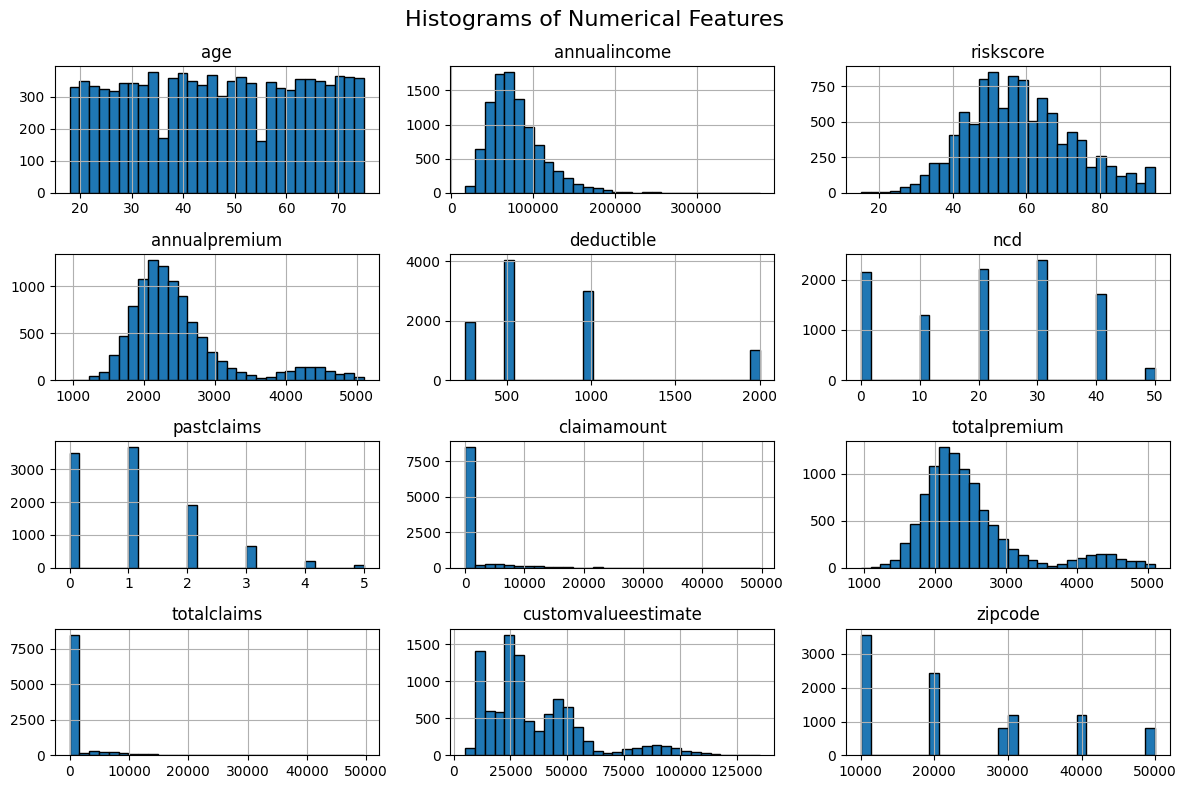

In [10]:
plot_histograms(df)

### Bivariate / Multivariate Analysis 

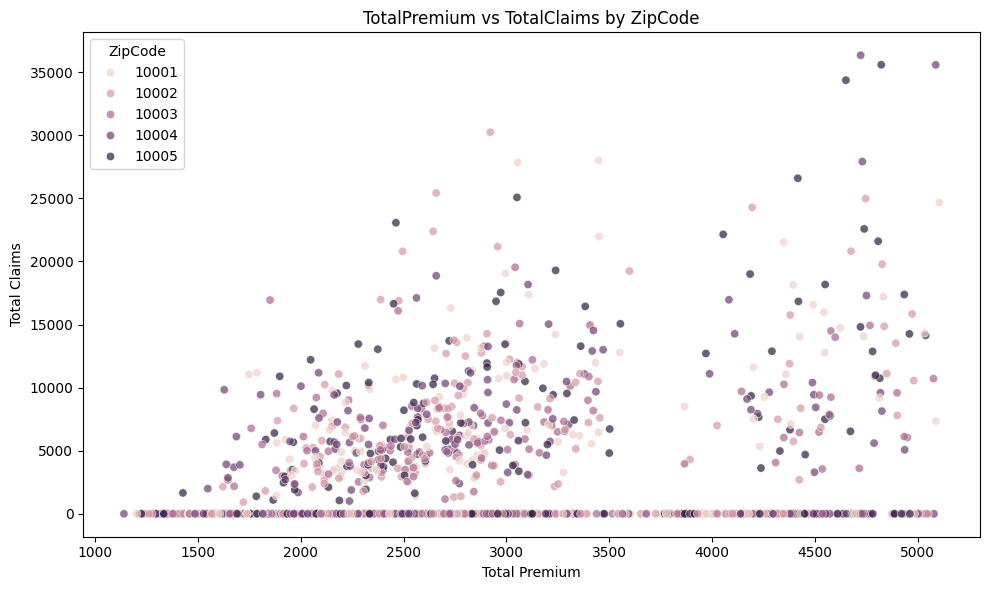

In [18]:
# Scatter plot
plot_scatter_by_zipcode(df)

In [20]:
# Correlation table
corr_df = correlation_by_zipcode(df)
print(corr_df)

    zipcode  Correlation
18    40004     0.460901
4     10005     0.426410
6     20002     0.414870
14    30005     0.408442
15    40001     0.385992
19    40005     0.382420
10    30001     0.381697
9     20005     0.377629
0     10001     0.375667
24    50005     0.362993
23    50004     0.356223
13    30004     0.325046
17    40003     0.319187
2     10003     0.318463
1     10002     0.307607
7     20003     0.306911
3     10004     0.298776
8     20004     0.280352
20    50001     0.278683
22    50003     0.276541
12    30003     0.263172
21    50002     0.251554
11    30002     0.245930
5     20001     0.175932
16    40002     0.132719


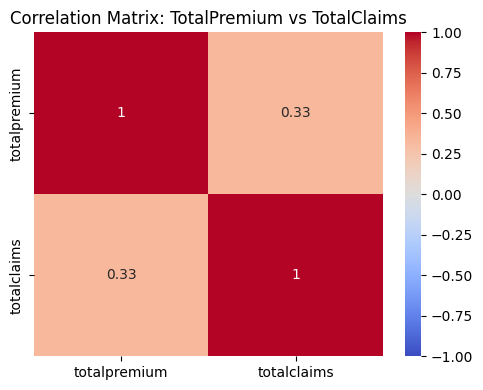

In [21]:
# Heatmap
plot_correlation_heatmap(df)

### Geographic Trends 

In [26]:
# Average premium analysis
print(premium_by_province(df))

      province  totalpremium
0       Somali   2521.101351
1  Addis Ababa   2497.161200
2       Oromia   2481.464841
3       Tigray   2475.985075
4       Amhara   2465.515758


In [27]:
# Cover type distribution
print(cover_type_distribution(df))

covertype    Comprehensive  Third Party Fire & Theft  Third Party Only
province                                                              
Addis Ababa           1719                      1210               638
Amhara                 943                       660               396
Oromia                1139                       869               438
Somali                 549                       424               211
Tigray                 370                       290               144


In [28]:
# Auto make distribution
print(auto_make_distribution(df))

automake     BMW  Hyundai  Lifan  Mercedes-Benz  Suzuki  Toyota
province                                                       
Addis Ababa  132     1118    449            124     603    1141
Amhara        49      629    273             59     349     640
Oromia        83      706    339             69     419     830
Somali        41      351    124             47     203     418
Tigray        34      272     94             18     134     252


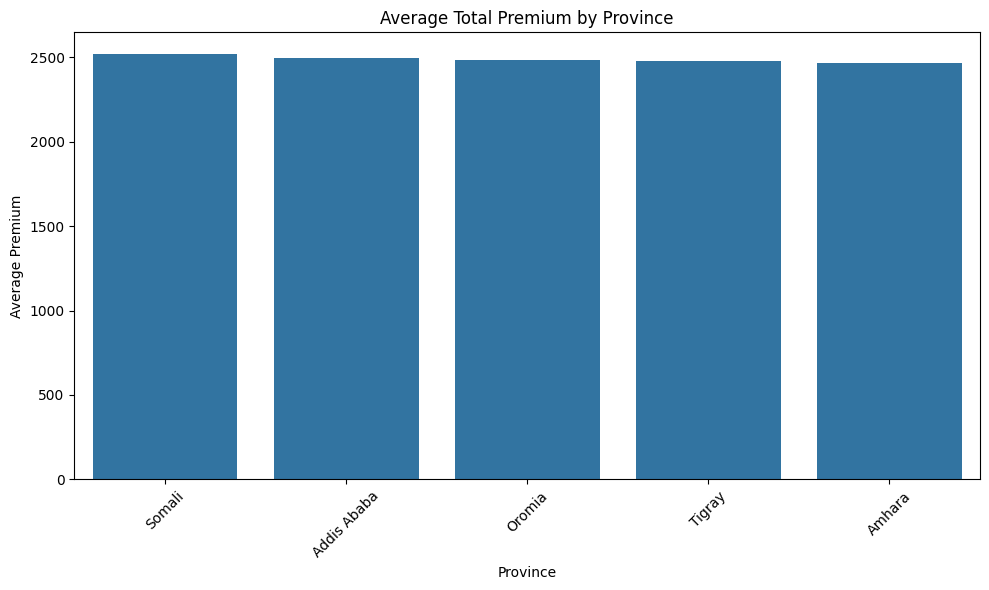

In [29]:
# Visualizations
plot_average_premium(df)

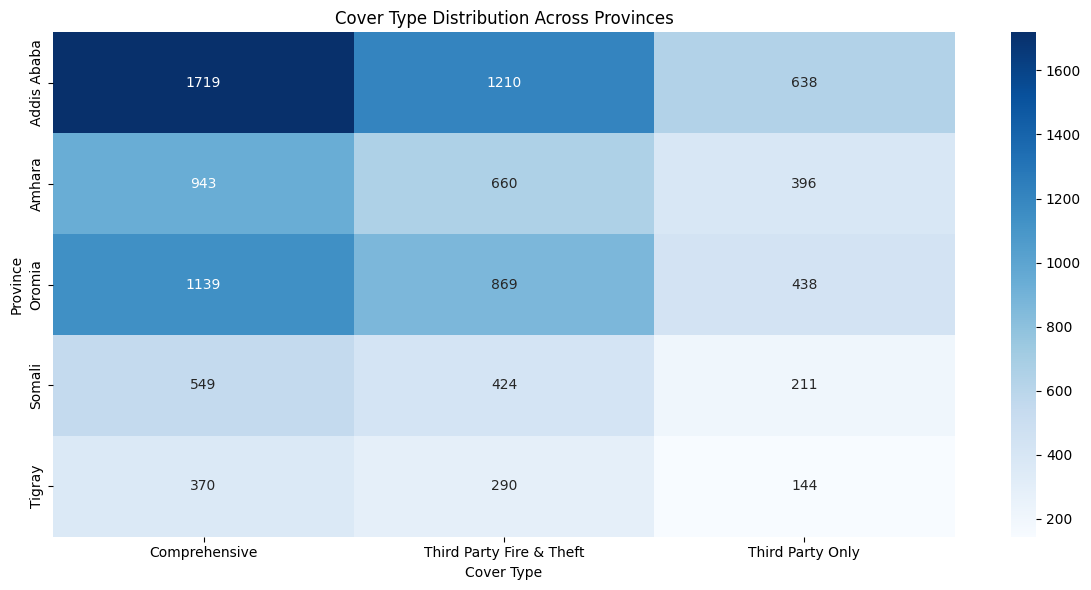

In [30]:
plot_cover_type_heatmap(df)

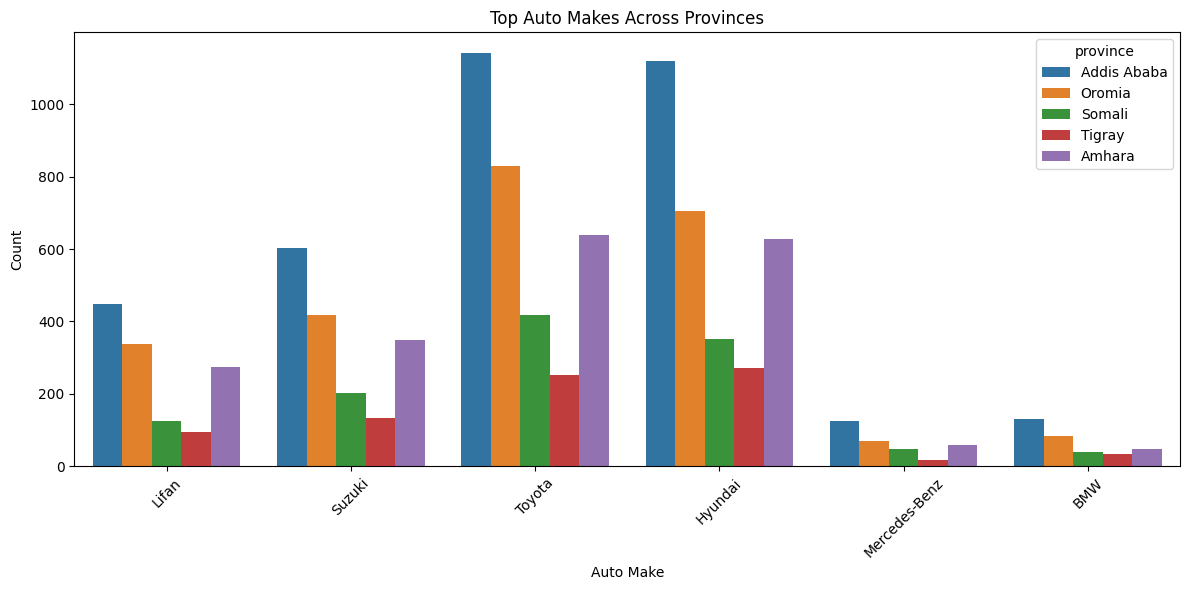

In [31]:
plot_top_auto_makes(df)

### Outlier Detection 

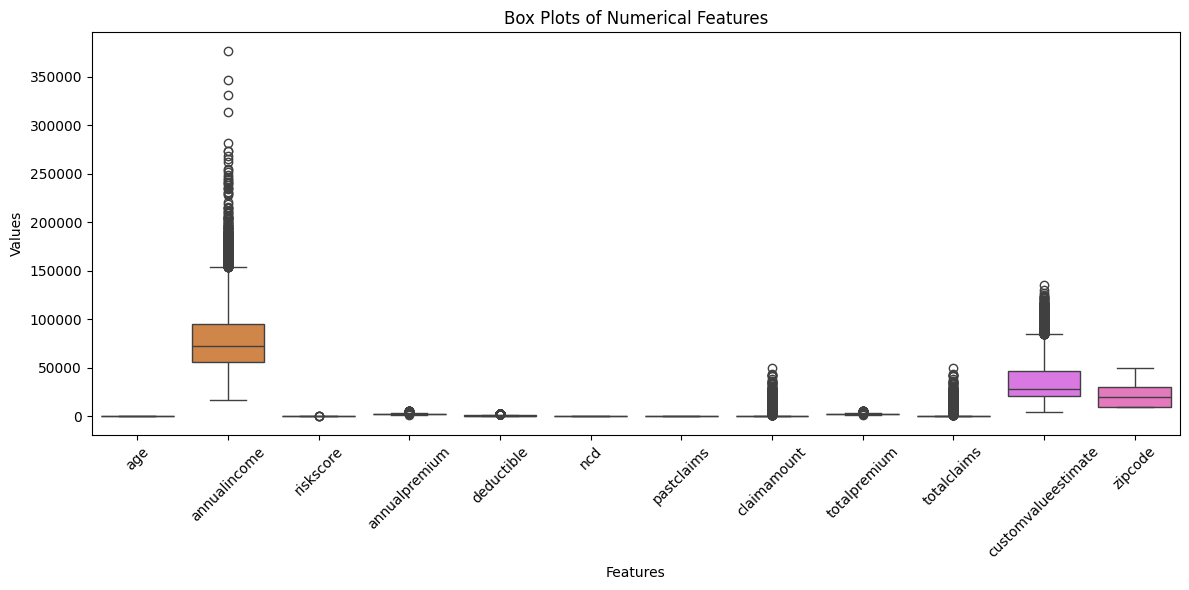

In [33]:
 # Combined boxplots
plot_boxplots(df)

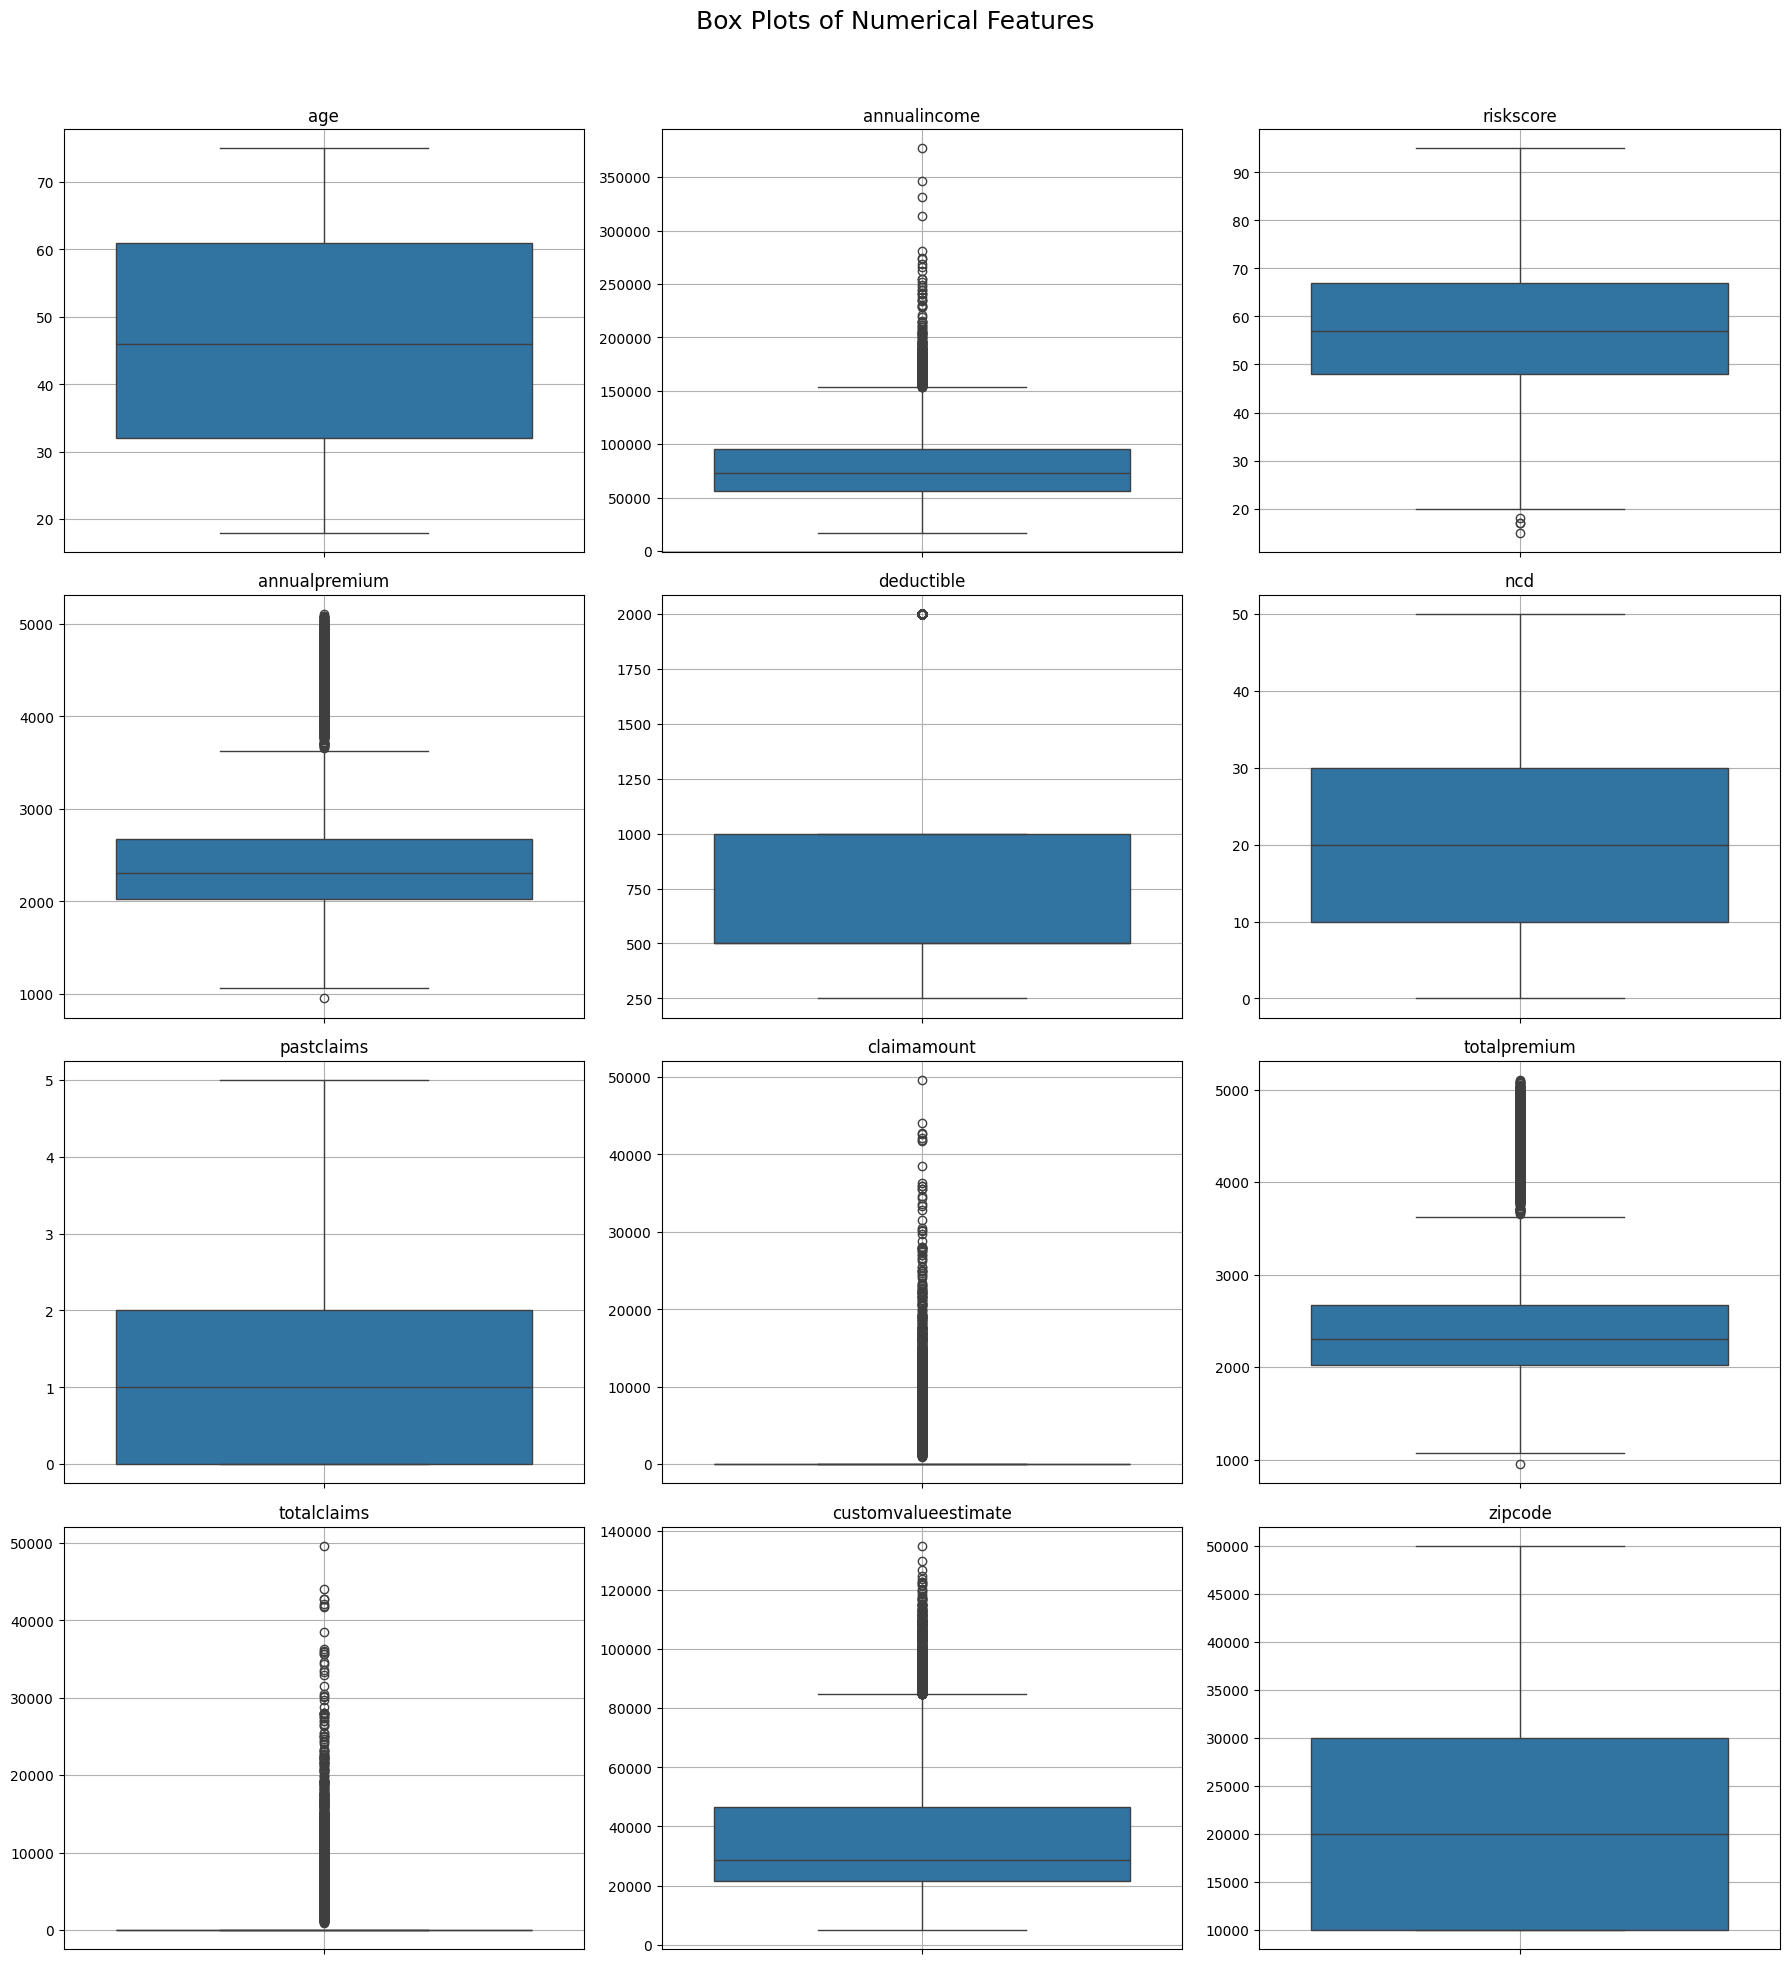

In [50]:
import math

# Individual boxplots
plot_individual_boxplots(df)

### The overall Loss Ratio for the portfolio

In [54]:
calculate_loss_ratio(df)

Overall Loss Ratio: 0.53


np.float64(0.5281836596904845)

             totalclaims  totalpremium  LossRatio
province                                         
Somali         1826593.0       2984984   0.611927
Oromia         3261061.0       6069663   0.537272
Tigray         1047136.0       1990692   0.526016
Addis Ababa    4653210.0       8907374   0.522400
Amhara         2353885.0       4928566   0.477600


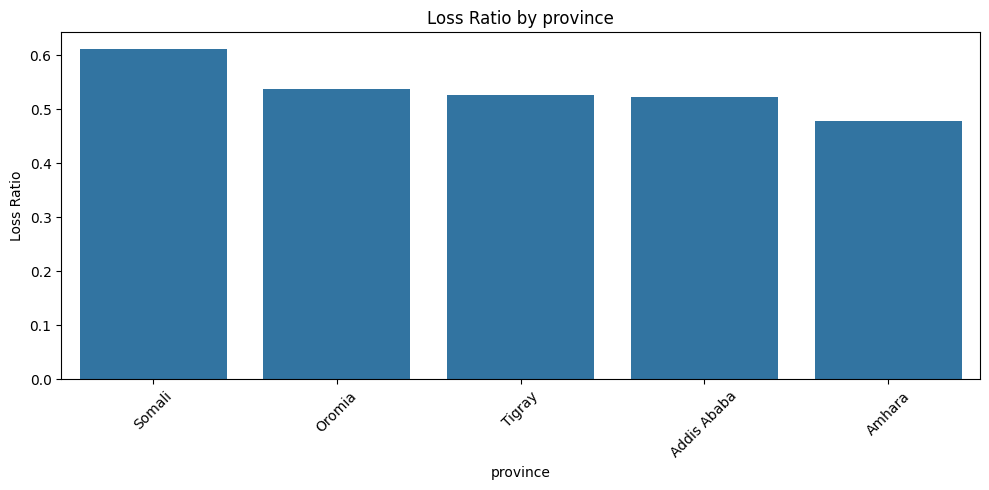

In [58]:

print(loss_ratio_by_group(df, "province"))

plot_loss_ratio(df, "province")

             totalclaims  totalpremium  LossRatio
vehicletype                                      
Luxury         3569207.0       4236839   0.842422
SUV            4090665.0       7256436   0.563729
Hatchback      1904235.0       4532134   0.420163
Sedan          3577778.0       8855870   0.404001


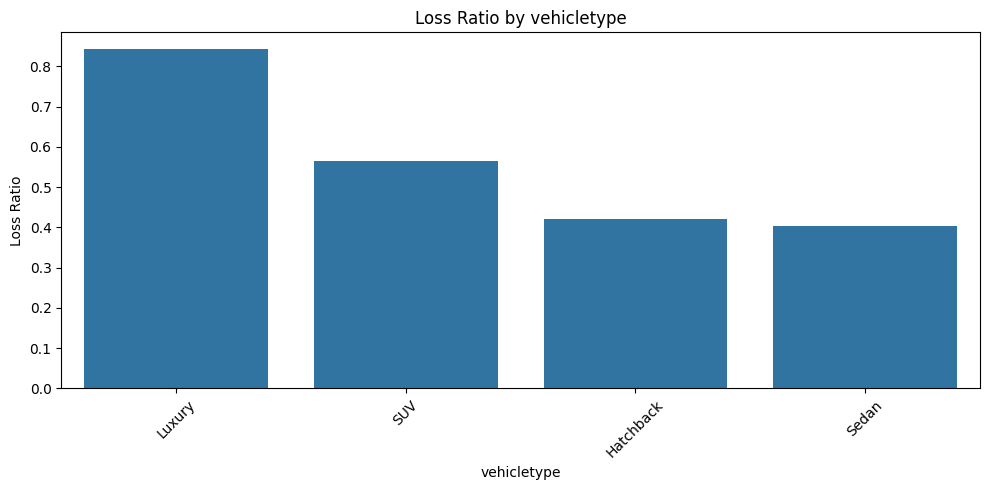

In [59]:
print(loss_ratio_by_group(df, "vehicletype"))

plot_loss_ratio(df, "vehicletype")


        totalclaims  totalpremium  LossRatio
gender                                      
Female    6763030.0      12791141   0.528728
Male      6378855.0      12090138   0.527608


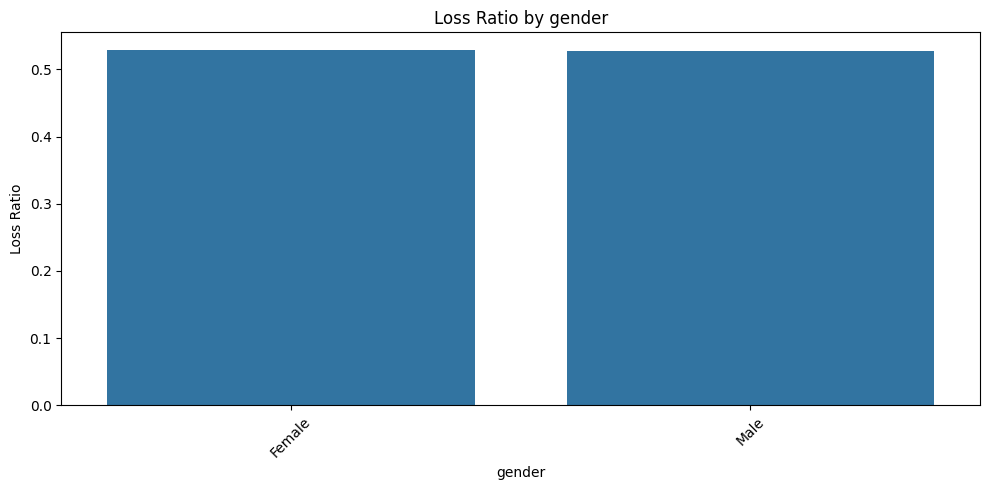

In [60]:
print(loss_ratio_by_group(df, "gender"))

plot_loss_ratio(df, "gender")

In [62]:
df.columns

Index(['customerid', 'age', 'gender', 'province', 'vehicletype',
       'annualincome', 'riskscore', 'annualpremium', 'deductible', 'ncd',
       'pastclaims', 'claimed', 'claimamount', 'totalpremium', 'totalclaims',
       'covertype', 'automake', 'vehiclemodel', 'customvalueestimate',
       'zipcode', 'transactiondate'],
      dtype='str')

### The distributions of key financial variables

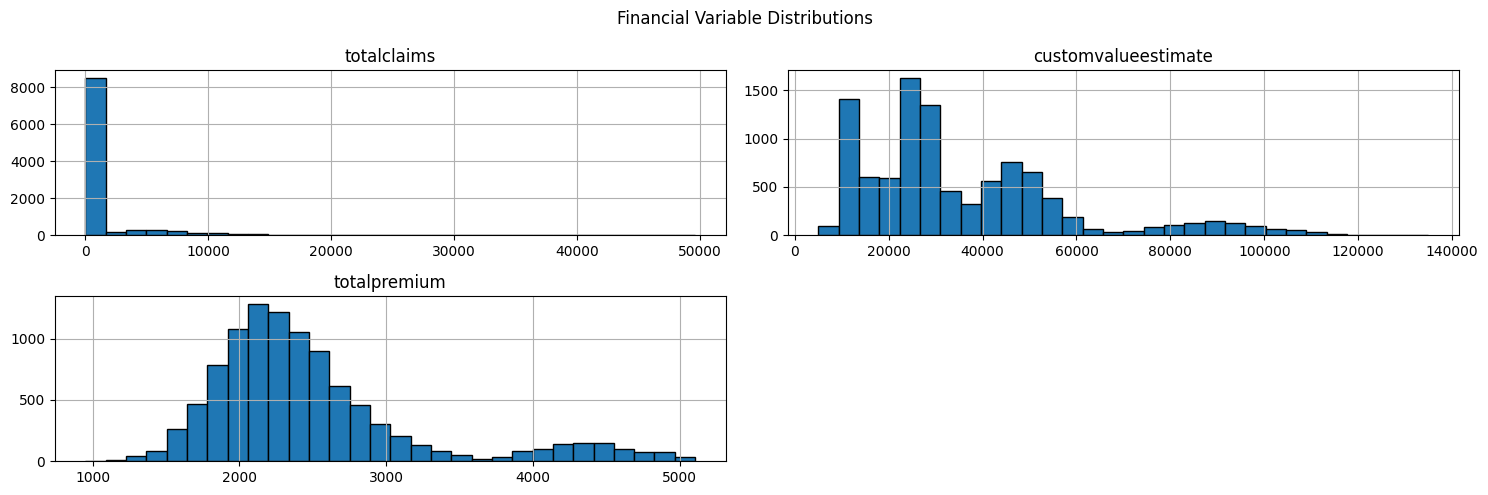

In [64]:
plot_financial_distributions(df)

In [66]:
detect_outliers_iqr(df, "totalclaims")

totalclaims Outliers: 1535


,customerid,age,gender,province,vehicletype,annualincome,riskscore,annualpremium,deductible,ncd,...,claimed,claimamount,totalpremium,totalclaims,covertype,automake,vehiclemodel,customvalueestimate,zipcode,transactiondate
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
11,AC-100011,28,Male,Tigray,Sedan,95735,67,2655,500,0,...,True,3583.0,2655,3583.0,Third Party Fire & Theft,Lifan,620,27903,50002,2025-03-02
21,AC-100021,19,Female,Oromia,SUV,79072,80,2822,500,0,...,True,3974.0,2822,3974.0,Comprehensive,Suzuki,Grand Vitara,45363,20004,2024-06-24
26,AC-100026,19,Male,Addis Ababa,Hatchback,56705,95,3551,250,0,...,True,12791.0,3551,12791.0,Comprehensive,Toyota,Vitz,13068,10001,2024-05-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9945,AC-109945,19,Male,Addis Ababa,Sedan,109324,71,2772,250,0,...,True,4205.0,2772,4205.0,Third Party Only,Lifan,620,25710,10001,2025-01-07
9953,AC-109953,33,Female,Somali,SUV,138710,58,2368,250,20,...,True,11450.0,2368,11450.0,Comprehensive,Toyota,RAV4,54574,40004,2024-08-05
9961,AC-109961,23,Male,Addis Ababa,SUV,62879,70,2773,1000,0,...,True,10114.0,2773,10114.0,Comprehensive,Hyundai,Tucson,53137,10004,2024-11-18
9967,AC-109967,19,Male,Addis Ababa,Hatchback,49335,83,3177,250,0,...,True,9950.0,3177,9950.0,Third Party Fire & Theft,Toyota,Vitz,13794,10005,2024-10-15


In [67]:
detect_outliers_iqr(df, "customvalueestimate")

customvalueestimate Outliers: 623


,customerid,age,gender,province,vehicletype,annualincome,riskscore,annualpremium,deductible,ncd,...,claimed,claimamount,totalpremium,totalclaims,covertype,automake,vehiclemodel,customvalueestimate,zipcode,transactiondate
35,AC-100035,44,Male,Amhara,Luxury,64738,76,4473,2000,0,...,False,0.0,4473,0.0,Comprehensive,Mercedes-Benz,E-Class,94369,30002,2024-08-12
41,AC-100041,68,Female,Addis Ababa,Luxury,61946,66,4118,1000,20,...,False,0.0,4118,0.0,Comprehensive,BMW,5 Series,102478,10001,2025-04-10
43,AC-100043,72,Female,Addis Ababa,Luxury,26675,72,4188,500,10,...,False,0.0,4188,0.0,Comprehensive,BMW,5 Series,90500,10002,2024-07-09
46,AC-100046,20,Male,Somali,Luxury,76518,95,4959,1000,0,...,True,11547.0,4959,11547.0,Comprehensive,BMW,5 Series,117270,40005,2025-03-11
67,AC-100067,61,Male,Addis Ababa,Luxury,62230,74,4446,250,30,...,False,0.0,4446,0.0,Comprehensive,BMW,5 Series,104400,10003,2024-10-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9937,AC-109937,51,Male,Oromia,Luxury,73864,89,4699,500,40,...,False,0.0,4699,0.0,Comprehensive,BMW,5 Series,86944,20003,2024-01-13
9942,AC-109942,62,Male,Addis Ababa,Luxury,228851,66,3930,500,40,...,False,0.0,3930,0.0,Comprehensive,BMW,5 Series,103485,10002,2024-11-30
9950,AC-109950,74,Male,Amhara,Luxury,129920,81,4555,500,20,...,False,0.0,4555,0.0,Third Party Fire & Theft,BMW,5 Series,114962,30001,2025-06-19
9956,AC-109956,24,Female,Oromia,Luxury,55474,86,4626,1000,0,...,False,0.0,4626,0.0,Comprehensive,BMW,5 Series,87798,20002,2024-09-23


### Temporal Trends

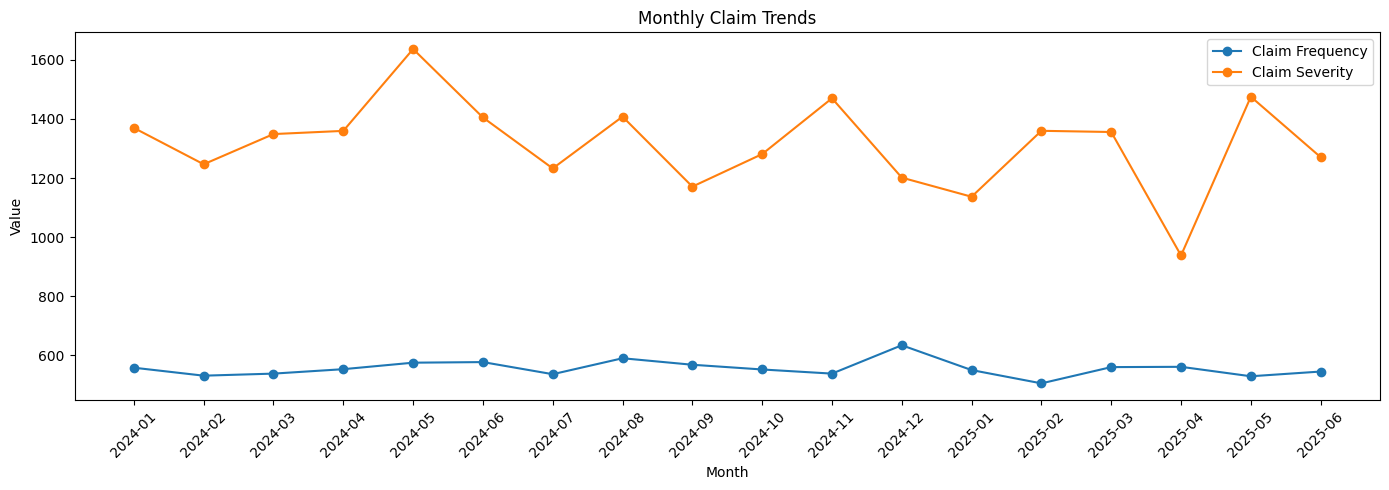

In [70]:
plot_claim_trends(df, "transactiondate")

### Vehicle Claim Analysis

In [72]:
vehicle_claim_analysis(df, "automake")


Highest Claim Vehicles
automake
Mercedes-Benz    3787.012618
BMW              3362.890855
Toyota           1372.520878
Suzuki           1122.025761
Hyundai          1042.739272
Lifan             918.103987
Name: totalclaims, dtype: float64

Lowest Claim Vehicles
automake
Mercedes-Benz    3787.012618
BMW              3362.890855
Toyota           1372.520878
Suzuki           1122.025761
Hyundai          1042.739272
Lifan             918.103987
Name: totalclaims, dtype: float64


automake
Mercedes-Benz    3787.012618
BMW              3362.890855
Toyota           1372.520878
Suzuki           1122.025761
Hyundai          1042.739272
Lifan             918.103987
Name: totalclaims, dtype: float64

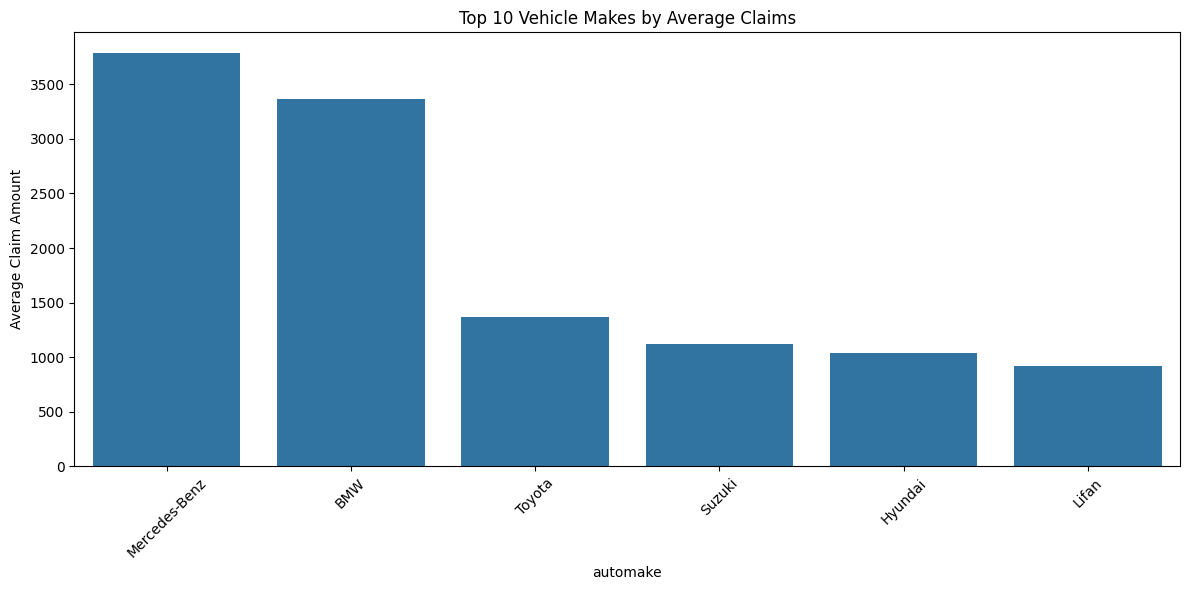

In [73]:
plot_vehicle_claims(df, "automake")

### 3 creative and well-designed 

In [82]:
# Rename AutoMake to VehicleMake
df = df.rename(columns={'automake': 'VehicleMake'})

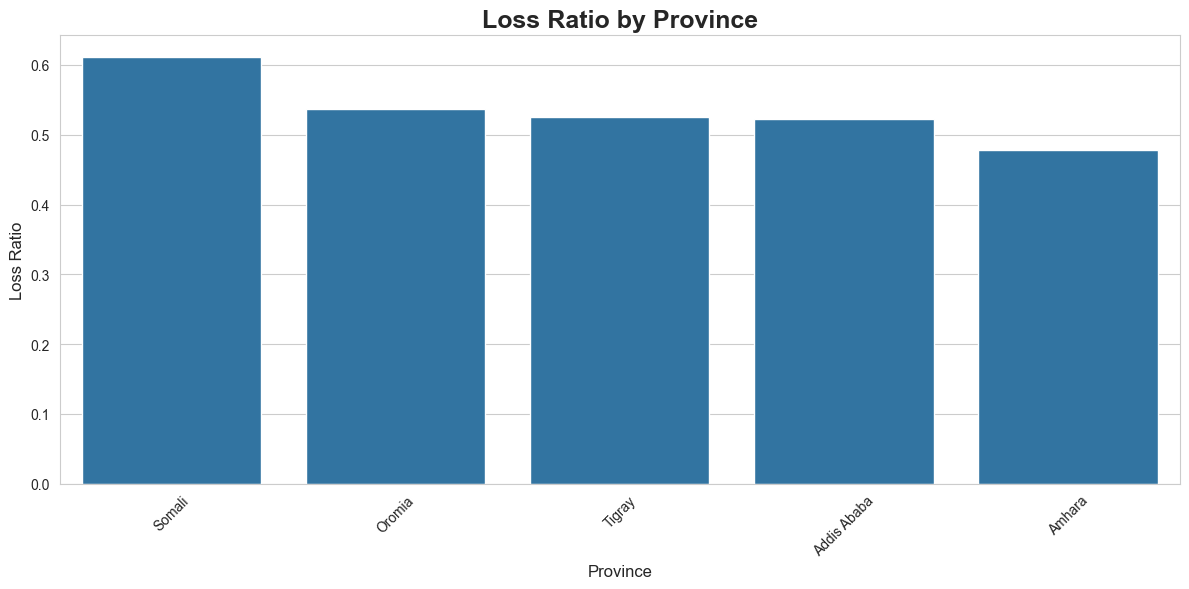

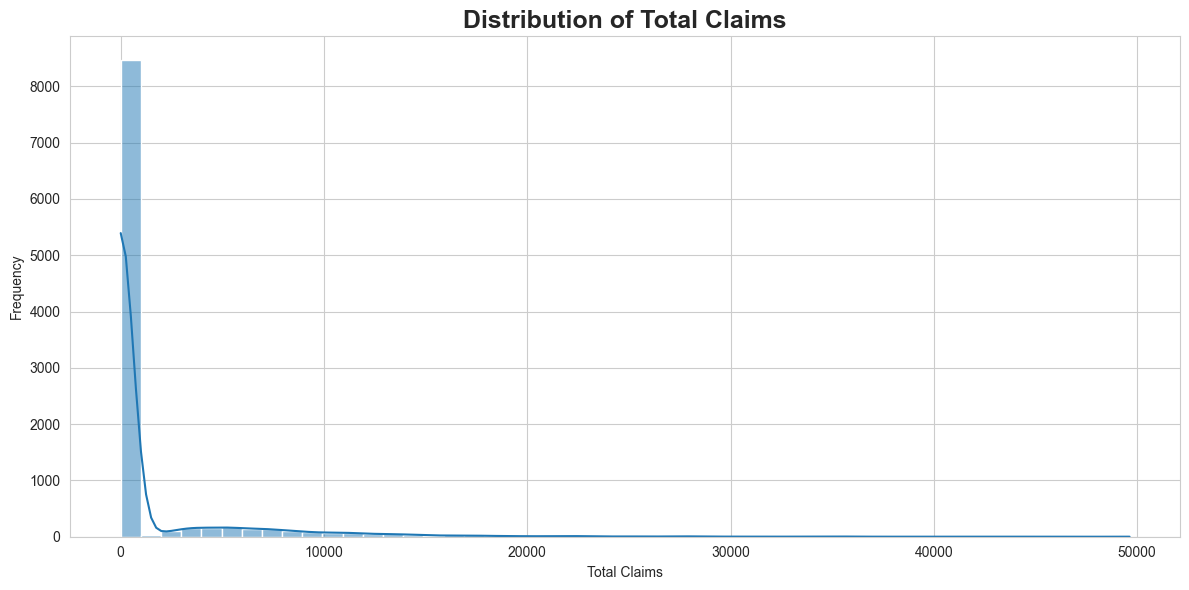

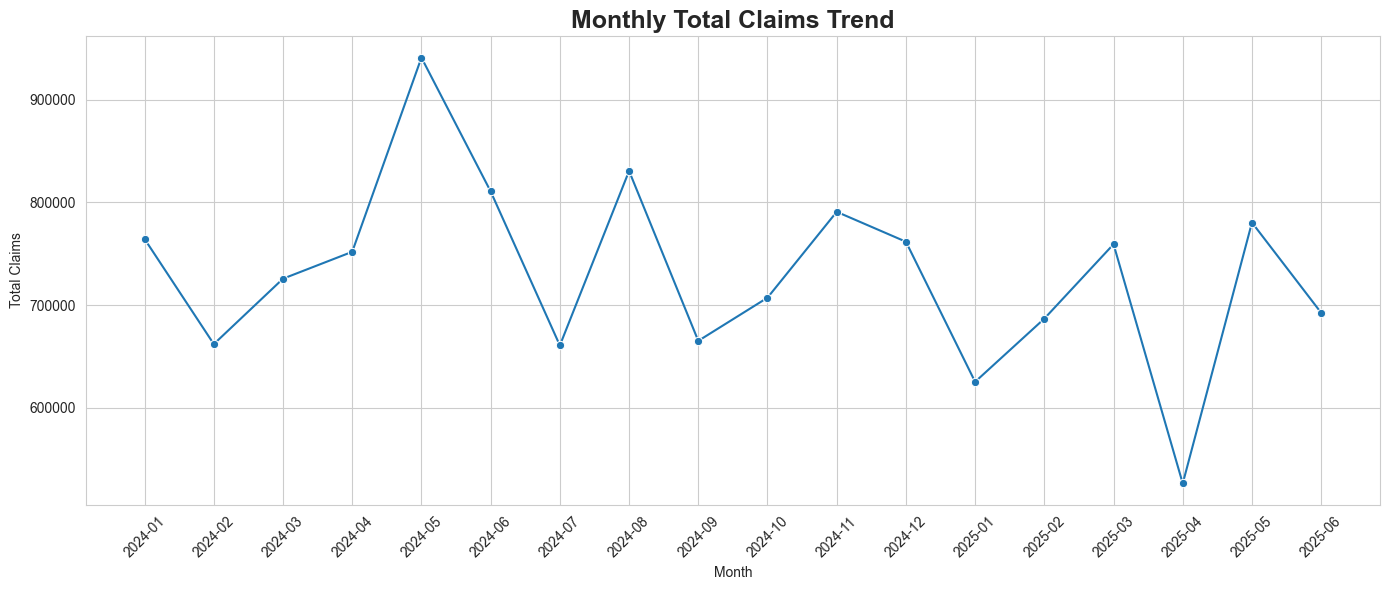

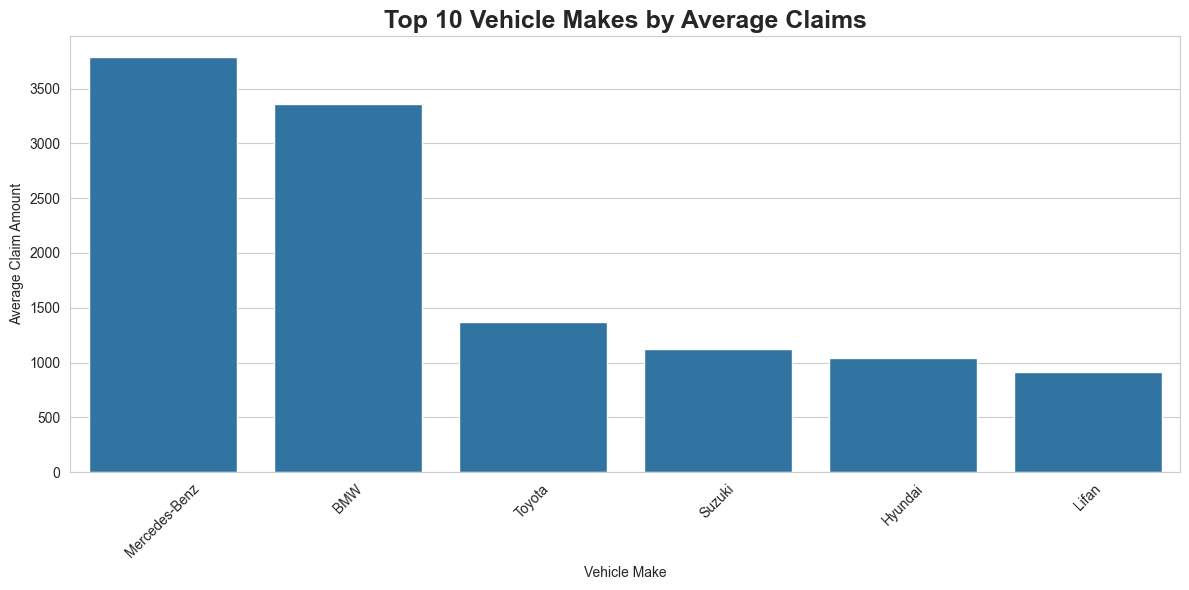

In [84]:
 # Generate plots
run_eda_visualizations(df)